In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

from xgboost import XGBRegressor

import shap

In [2]:
from pathlib import Path

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent.parent
PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"

print(PROCESSED_DIR)

C:\Users\Sameen\10 Pearls Project\AQI Predictor\Data\Processed


In [3]:
# df = pd.read_csv(PROCESSED_DIR / "Aqi_Data_Two_Day_Prediction_New.csv", index_col="time", parse_dates=True)
# df.info()

In [4]:
# df.head()

# Train And Test Split

In [5]:
# df.columns

In [6]:
# X = df.drop(columns = ['Day_2_Future_AQI'])
# Y = df['Day_2_Future_AQI']

In [7]:
# X

In [8]:
# Y

In [9]:
# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle = False)

In [10]:
# len(X_train)

In [11]:
# len(X_test)

# Building XGBoost Model For Day Two

In [12]:
# model = XGBRegressor(n_estimators = 520, 
#                      learning_rate = 0.033,
#                      max_depth = 3, 
#                      random_state = 42, 
#                      colsample_bytree = 0.7, 
#                      subsample = 0.7,
#                      min_child_weight = 5,
#                      gamma=0.1,
#                      reg_alpha=0.1,
#                      reg_lambda=1.5,
#                     ) 

In [13]:
# model.fit(X_train, Y_train)

In [14]:
# y_pred = model.predict(X_test)

# Evaluating the Model

In [15]:
# R2_Score = r2_score(Y_test, y_pred)
# Mae = mean_absolute_error(Y_test, y_pred)
# Mean_Square_Error = mean_squared_error(Y_test, y_pred)
# Root_Mean_Square_Error = np.sqrt(Mean_Square_Error)

# print("Evaluation Metrics: ")
# print(f"R2 Score: {R2_Score}")
# print(f"Mean Absolute Error: {Mae}")
# print(f"Mean Square Error: {Mean_Square_Error}")
# print(f"Root Mean Square Error: {Root_Mean_Square_Error}")

# Note:
- Not much Improvement will come even if I do hyper parameter optimization. I will try other method

# Now Day Wise

In [16]:
import os
from dotenv import load_dotenv
import hopsworks

In [17]:
load_dotenv(PROJECT_ROOT / ".env")

key = os.getenv("HOPSWORK_KEY")

In [18]:
project = hopsworks.login(
    project='aqi_karachi_samu_2026',
    host="eu-west.cloud.hopsworks.ai",
    port=443,
    api_key_value=key,
)

fs = project.get_feature_store()
print(f"Connected to {project.name}")

2026-08-23 00:55:13,842 INFO: Initializing external client
2026-08-23 00:55:13,844 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-23 00:55:18,030 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41193
Connected to aqi_karachi_samu_2026


In [19]:
target = "day_2_future_aqi"
day_2_fv = fs.get_feature_view(name="view_aqi_day2", version=1)

In [20]:
x, y = day_2_fv.training_data()

Reading data from Hopsworks, using Hopsworks Feature Query Service.     

2026-08-23 00:55:34,453 INFO: Computing insert statistics


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (4.37s) 


In [21]:
day2 = x.copy()
day2[target] = y[target]

In [22]:
day2.time = pd.to_datetime(day2.time)
day2 = day2.sort_values("time").set_index("time")

In [23]:
day2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1090 entries, 2023-08-04 00:00:00+00:00 to 2026-07-28 00:00:00+00:00
Data columns (total 52 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperature_2m               1090 non-null   float64
 1   wind_speed_10m               1090 non-null   float64
 2   relative_humidity_2m         1090 non-null   float64
 3   surface_pressure             1090 non-null   float64
 4   boundary_layer_height        909 non-null    float64
 5   dew_point_2m                 1090 non-null   float64
 6   precipitation                1090 non-null   float64
 7   cloud_cover                  1090 non-null   float64
 8   wind_direction_10m           1090 non-null   float64
 9   wind_gusts_10m               1090 non-null   float64
 10  shortwave_radiation          1090 non-null   float64
 11  pm10                         1090 non-null   float64
 12  pm2_5                       

In [24]:
day2.head()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,cyclic_day_sin,cyclic_day_cos,cyclic_week_sin,cyclic_week_cos,delta_temperature_2m,delta_wind_speed_10m,delta_surface_pressure,delta_relative_humidity_2m,delta_boundary_layer_height,day_2_future_aqi
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+00:00,28.441667,20.516667,83.458333,1000.087500,752.708333,25.291667,0.037500,50.083333,245.083333,31.941667,...,-0.545240,-0.838280,-0.433884,-0.900969,-0.208333,10.162500,1.520833,-3.083333,147.708333,78.833333
2023-08-05 00:00:00+00:00,28.329167,21.941667,81.750000,1002.600000,818.333333,24.866667,0.037500,69.833333,247.750000,33.450000,...,-0.559589,-0.828770,-0.974928,-0.222521,-0.287500,11.279167,-3.608333,-1.541667,98.125000,78.875000
2023-08-06 00:00:00+00:00,28.233333,30.679167,80.375000,1001.608333,900.416667,24.479167,0.029167,81.625000,254.500000,45.562500,...,-0.573772,-0.819015,-0.781831,0.623490,-0.237500,-1.250000,-2.245833,1.291667,-95.000000,78.791667
2023-08-07 00:00:00+00:00,28.041667,33.220833,80.208333,998.991667,916.458333,24.266667,0.070833,75.000000,250.250000,49.770833,...,-0.587785,-0.809017,0.000000,1.000000,-0.070833,-4.783333,3.595833,1.416667,-117.708333,73.416667
2023-08-08 00:00:00+00:00,27.995833,29.429167,81.666667,999.362500,805.416667,24.512500,0.091667,68.541667,245.916667,44.275000,...,-0.601624,-0.798779,0.781831,0.623490,-0.166667,-1.858333,4.245833,0.791667,-29.375000,68.791667


In [25]:
day2.columns

Index(['temperature_2m', 'wind_speed_10m', 'relative_humidity_2m',
       'surface_pressure', 'boundary_layer_height', 'dew_point_2m',
       'precipitation', 'cloud_cover', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'pm10', 'pm2_5', 'carbon_monoxide',
       'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust',
       'aerosol_optical_depth', 'us_aqi', 'month', 'dayofweek',
       'previous_day_aqi', 'rolled_mean_aqi_24hr', 'rolled_mean_aqi_72hr',
       'rolled_std_aqi_24hr', 'rolled_std_aqi_72hr', 'ewm_aqi_24hr',
       'ewm_std_24hr', 'f48_temperature_2m', 'f48_wind_speed_10m',
       'f48_relative_humidity_2m', 'f48_surface_pressure',
       'f48_boundary_layer_height', 'f48_dew_point_2m', 'f48_precipitation',
       'f48_cloud_cover', 'f48_wind_gusts_10m', 'f48_shortwave_radiation',
       'wind_pollution_dispersion', 'pressure_change_3hour', 'humidity_level',
       'cyclic_day_sin', 'cyclic_day_cos', 'cyclic_week_sin',
       'cyclic_week_cos', 'del

In [26]:
X1 = day2.drop(columns = [target])
Y1 = day2[target]

In [27]:
X1

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,humidity_level,cyclic_day_sin,cyclic_day_cos,cyclic_week_sin,cyclic_week_cos,delta_temperature_2m,delta_wind_speed_10m,delta_surface_pressure,delta_relative_humidity_2m,delta_boundary_layer_height
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+00:00,28.441667,20.516667,83.458333,1000.087500,752.708333,25.291667,0.037500,50.083333,245.083333,31.941667,...,3.150000,-0.545240,-0.838280,-0.433884,-0.900969,-0.208333,10.162500,1.520833,-3.083333,147.708333
2023-08-05 00:00:00+00:00,28.329167,21.941667,81.750000,1002.600000,818.333333,24.866667,0.037500,69.833333,247.750000,33.450000,...,3.462500,-0.559589,-0.828770,-0.974928,-0.222521,-0.287500,11.279167,-3.608333,-1.541667,98.125000
2023-08-06 00:00:00+00:00,28.233333,30.679167,80.375000,1001.608333,900.416667,24.479167,0.029167,81.625000,254.500000,45.562500,...,3.754167,-0.573772,-0.819015,-0.781831,0.623490,-0.237500,-1.250000,-2.245833,1.291667,-95.000000
2023-08-07 00:00:00+00:00,28.041667,33.220833,80.208333,998.991667,916.458333,24.266667,0.070833,75.000000,250.250000,49.770833,...,3.775000,-0.587785,-0.809017,0.000000,1.000000,-0.070833,-4.783333,3.595833,1.416667,-117.708333
2023-08-08 00:00:00+00:00,27.995833,29.429167,81.666667,999.362500,805.416667,24.512500,0.091667,68.541667,245.916667,44.275000,...,3.483333,-0.601624,-0.798779,0.781831,0.623490,-0.166667,-1.858333,4.245833,0.791667,-29.375000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-24 00:00:00+00:00,30.233333,9.304167,76.625000,997.970833,503.958333,25.545833,0.000000,77.375000,233.250000,26.816667,...,4.687500,-0.377708,-0.925925,-0.433884,-0.900969,-0.545833,1.162500,2.883333,-3.625000,95.000000
2026-07-25 00:00:00+00:00,29.541667,10.587500,76.500000,999.633333,583.750000,24.916667,0.000000,98.833333,244.375000,28.675000,...,4.625000,-0.393590,-0.919286,-0.974928,-0.222521,0.287500,3.675000,0.229167,-3.375000,186.458333
2026-07-26 00:00:00+00:00,29.687500,10.466667,73.000000,1000.854167,598.958333,24.254167,0.000000,78.416667,262.625000,27.916667,...,5.433333,-0.409356,-0.912375,-0.781831,0.623490,-0.237500,5.154167,-3.266667,2.458333,137.083333


In [28]:
Y1

time
2023-08-04 00:00:00+00:00    78.833333
2023-08-05 00:00:00+00:00    78.875000
2023-08-06 00:00:00+00:00    78.791667
2023-08-07 00:00:00+00:00    73.416667
2023-08-08 00:00:00+00:00    68.791667
                               ...    
2026-07-24 00:00:00+00:00    82.041667
2026-07-25 00:00:00+00:00    83.250000
2026-07-26 00:00:00+00:00    78.708333
2026-07-27 00:00:00+00:00    79.125000
2026-07-28 00:00:00+00:00    80.416667
Name: day_2_future_aqi, Length: 1090, dtype: float64

In [29]:
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X1, Y1, test_size=0.2, shuffle = False)

In [30]:
len(X_train1)

872

In [31]:
len(X_test1)

218

# Building XGBoost Model For Day Two

In [32]:
model1 = XGBRegressor(n_estimators = 520, 
                     learning_rate = 0.033,
                     max_depth = 3, 
                     random_state = 42, 
                     colsample_bytree = 0.7, 
                     subsample = 0.7,
                     min_child_weight = 5,
                     gamma=0.1,
                     reg_alpha=0.1,
                     reg_lambda=1.5,
                    ) 

model1.fit(X_train1, Y_train1)
y_pred1 = model1.predict(X_test1)

# Evaluating the Model

In [33]:
R2_Score1 = r2_score(Y_test1, y_pred1)
Mae1 = mean_absolute_error(Y_test1, y_pred1)
Mean_Square_Error1 = mean_squared_error(Y_test1, y_pred1)
Root_Mean_Square_Error1 = np.sqrt(Mean_Square_Error1)

print("Evaluation Metrics: ")
print(f"R2 Score: {R2_Score1}")
print(f"Mean Absolute Error: {Mae1}")
print(f"Mean Square Error: {Mean_Square_Error1}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error1}")

Evaluation Metrics: 
R2 Score: 0.5305442683962904
Mean Absolute Error: 9.272831248945417
Mean Square Error: 168.74812847481255
Root Mean Square Error: 12.9903090215288


# Baseline Prediction For Day Two

In [34]:
y_pred_baseline = X_test1['us_aqi']
R2_Score_baseline = r2_score(Y_test1, y_pred_baseline)

In [35]:
R2_Score_baseline

0.1901201067864633

### So the Gain

In [36]:
R2_Score1 - R2_Score_baseline

0.34042416160982714

# Hyper Parameter Optimization Random Search 

In [37]:
random_grid = {
    "n_estimators":     [150, 300, 500, 700, 900],
    "learning_rate":    [0.005, 0.007, 0.01, 0.015, 0.02, 0.03],
    "max_depth":        [2, 3, 4],                    
    "min_child_weight": [10, 15, 20, 25, 30],        
    "gamma":            [0.5, 1.0, 1.5, 2.0, 3.0],   
    "subsample":        [0.5, 0.6, 0.7, 0.8],
    "colsample_bytree": [0.4, 0.5, 0.6, 0.7],
    "reg_alpha":        [0.1, 0.5, 1, 2, 5],          
    "reg_lambda":       [2, 5, 10, 20, 50],           
}

In [38]:
ts = TimeSeriesSplit(n_splits = 5, test_size = 90)

xg_random = RandomizedSearchCV(estimator = XGBRegressor(tree_method = 'hist', n_jobs =1, random_state =42),
                               param_distributions = random_grid,
                               n_iter = 100, 
                               cv = ts,
                               random_state = 42,
                               n_jobs=-1)

xg_random.fit(X_train1, Y_train1)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.4, 0.5, ...], 'gamma': [0.5, 1.0, ...], 'learning_rate': [0.005, 0.007, ...], 'max_depth': [2, 3, ...], ...}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl... test_size=90)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [39]:
def evaluate(model, test_features, test_labels):
  predictions = model.predict(test_features)
  r2 = r2_score(test_labels, predictions)
  mae1 = mean_absolute_error(test_labels, predictions)
  mse1 = mean_squared_error(test_labels, predictions)
  rmse1 = np.sqrt(mse1)
  print('Model Performance')
  print(f"R2 Score Fine Tuned Model: {r2}")
  print(f"Mean Absolute Error: {mae1}")
  print(f"Mean Square Error: {mse1}")
  print(f"Root Mean Square Error: {rmse1}")
  return r2

In [40]:
best_random = xg_random.best_estimator_
print(best_random)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.4, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=2.0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=1, num_parallel_tree=None, ...)


In [41]:
random_accuracy = evaluate(best_random,X_test1,Y_test1)

Model Performance
R2 Score Fine Tuned Model: 0.5353023273834725
Mean Absolute Error: 9.243316492903123
Mean Square Error: 167.0378212078911
Root Mean Square Error: 12.924311246944308


# SHAP STEP

### GET SHAP VALUES

In [42]:
explainer = shap.Explainer(best_random)
shap_values = explainer(X_test1)

### Waterfall Model

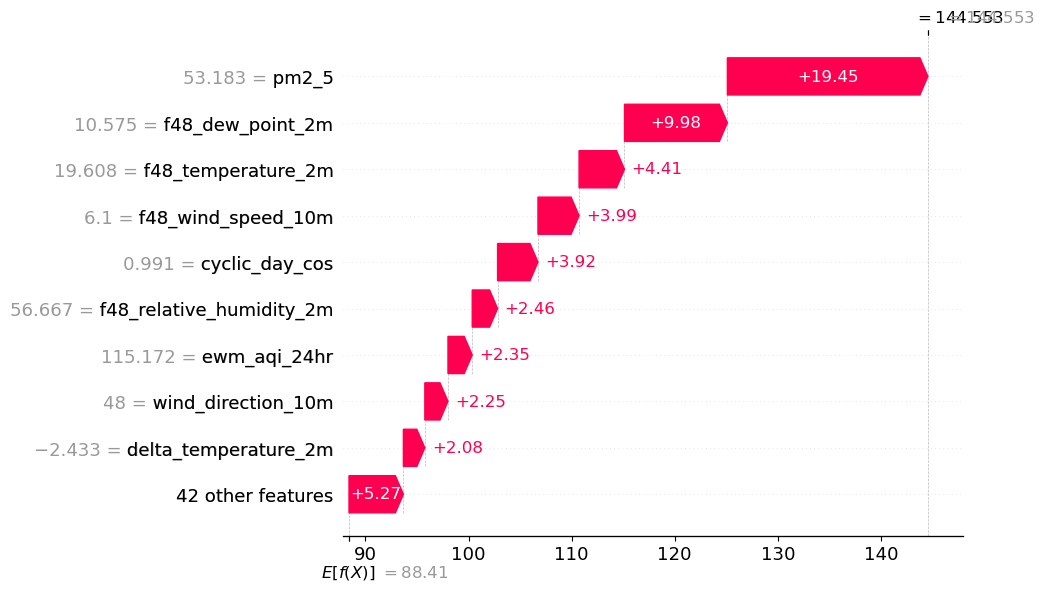

In [43]:
shap.plots.waterfall(shap_values[0])

### Beeswarm Plot

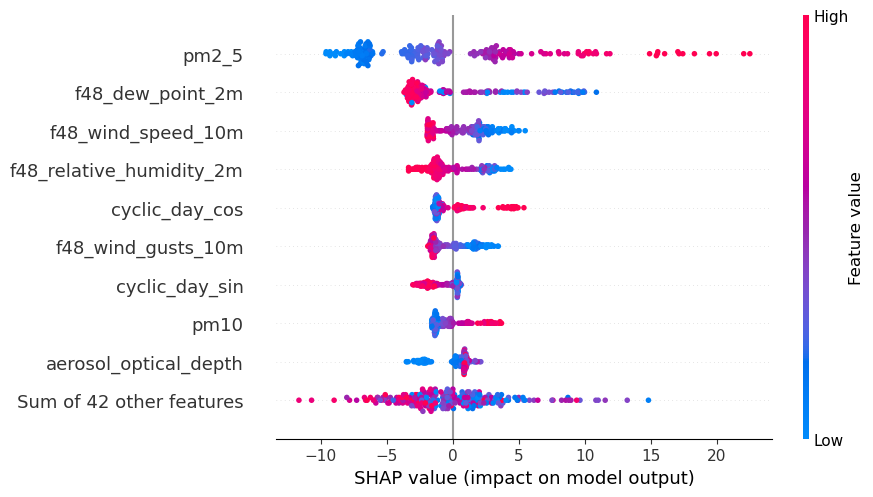

In [44]:
shap.plots.beeswarm(shap_values)

# Prediction Chart

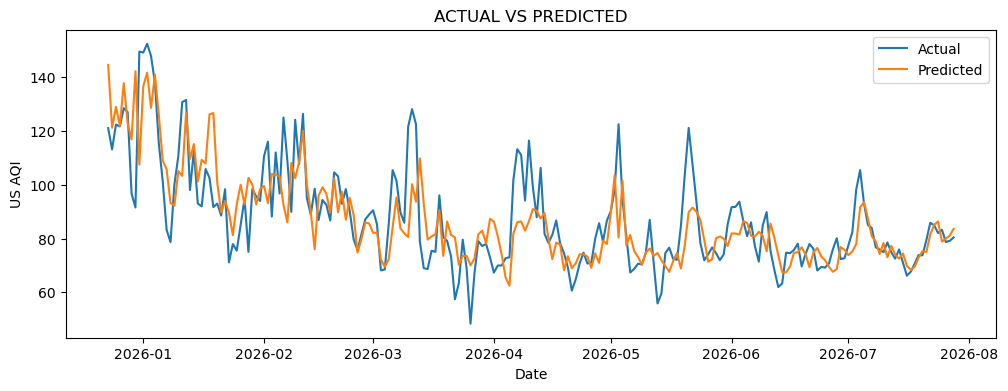

In [45]:
plt.figure(figsize=(12,4))
y_pred_tuned = best_random.predict(X_test1)
plt.plot(Y_test1.index, Y_test1.values, label="Actual")
plt.plot(Y_test1.index, y_pred_tuned, label="Predicted")
plt.legend(loc = "best")
plt.title("ACTUAL VS PREDICTED")
plt.ylabel("US AQI")
plt.xlabel("Date")
plt.show()

# Overfitting Test

In [46]:
train_Score = r2_score(Y_train1, best_random.predict(X_train1))
test_Score = r2_score(Y_test1, best_random.predict(X_test1))
print(f"Gap: {train_Score - test_Score}")

Gap: 0.35706705367490066
